**Installing required libraries**


In [7]:
pip install pytorch-tabnet

  Using cached pytorch_tabnet-4.1.0-py3-none-any.whl.metadata (15 kB)
Using cached pytorch_tabnet-4.1.0-py3-none-any.whl (44 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install torch

In [9]:
!pip install shap

  Using cached shap-0.51.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.3.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached shap-0.51.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.3.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multim

In [4]:
!pip install boto3

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import shap
import boto3
import sagemaker
import io

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, precision_score,
    average_precision_score, recall_score, f1_score
)
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from pytorch_tabnet.callbacks import Callback
from sagemaker import get_execution_role
from sagemaker.estimator import Estimator
from sagemaker.inputs import TrainingInput
from sagemaker.tuner import HyperparameterTuner, IntegerParameter, ContinuousParameter
from sagemaker import Model

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


In [33]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================

df = pd.read_csv('Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

In [7]:
# =============================================================================
# 2. DATA CLEANING
# =============================================================================

#df.drop(columns=['customerID'], inplace=True)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['Churn'].isnull().sum()

df = df.dropna(subset=['Churn'])

df['Churn'] = df['Churn'].astype(int)

df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

categorical_cols = df.select_dtypes(include=['object']).columns


print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")
print("\nData types:\n", df.dtypes)
print("\nClass balance:\n", df['Churn'].value_counts())



Missing values before cleaning:
TotalCharges    11
dtype: int64

Missing values after cleaning:
0 missing values remaining

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Class balance:
 Churn
0    5174
1    1869
Name: count, dtype: int64


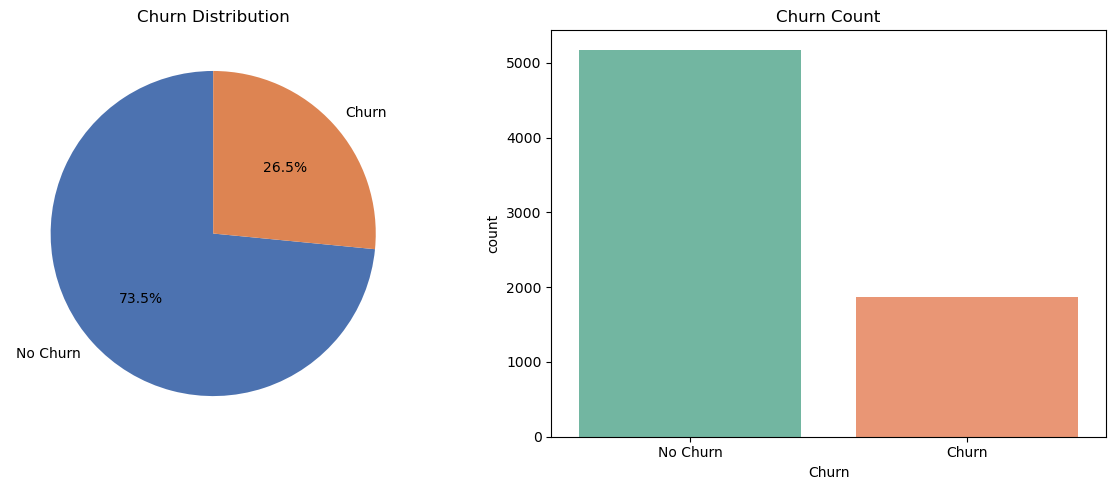

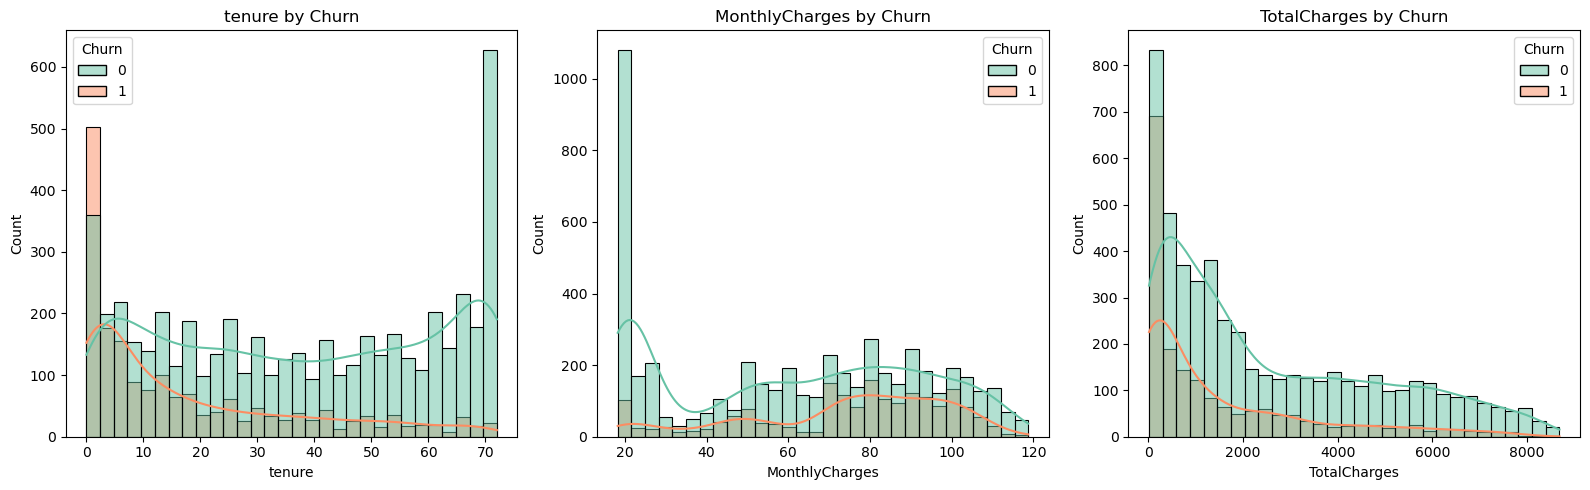

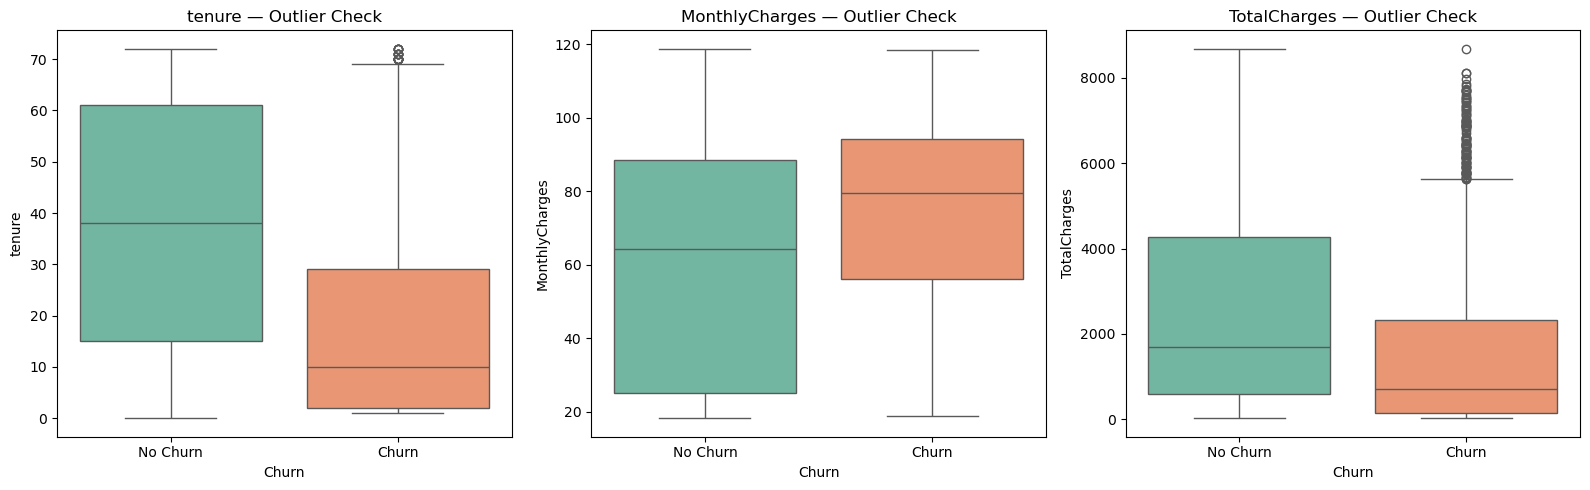

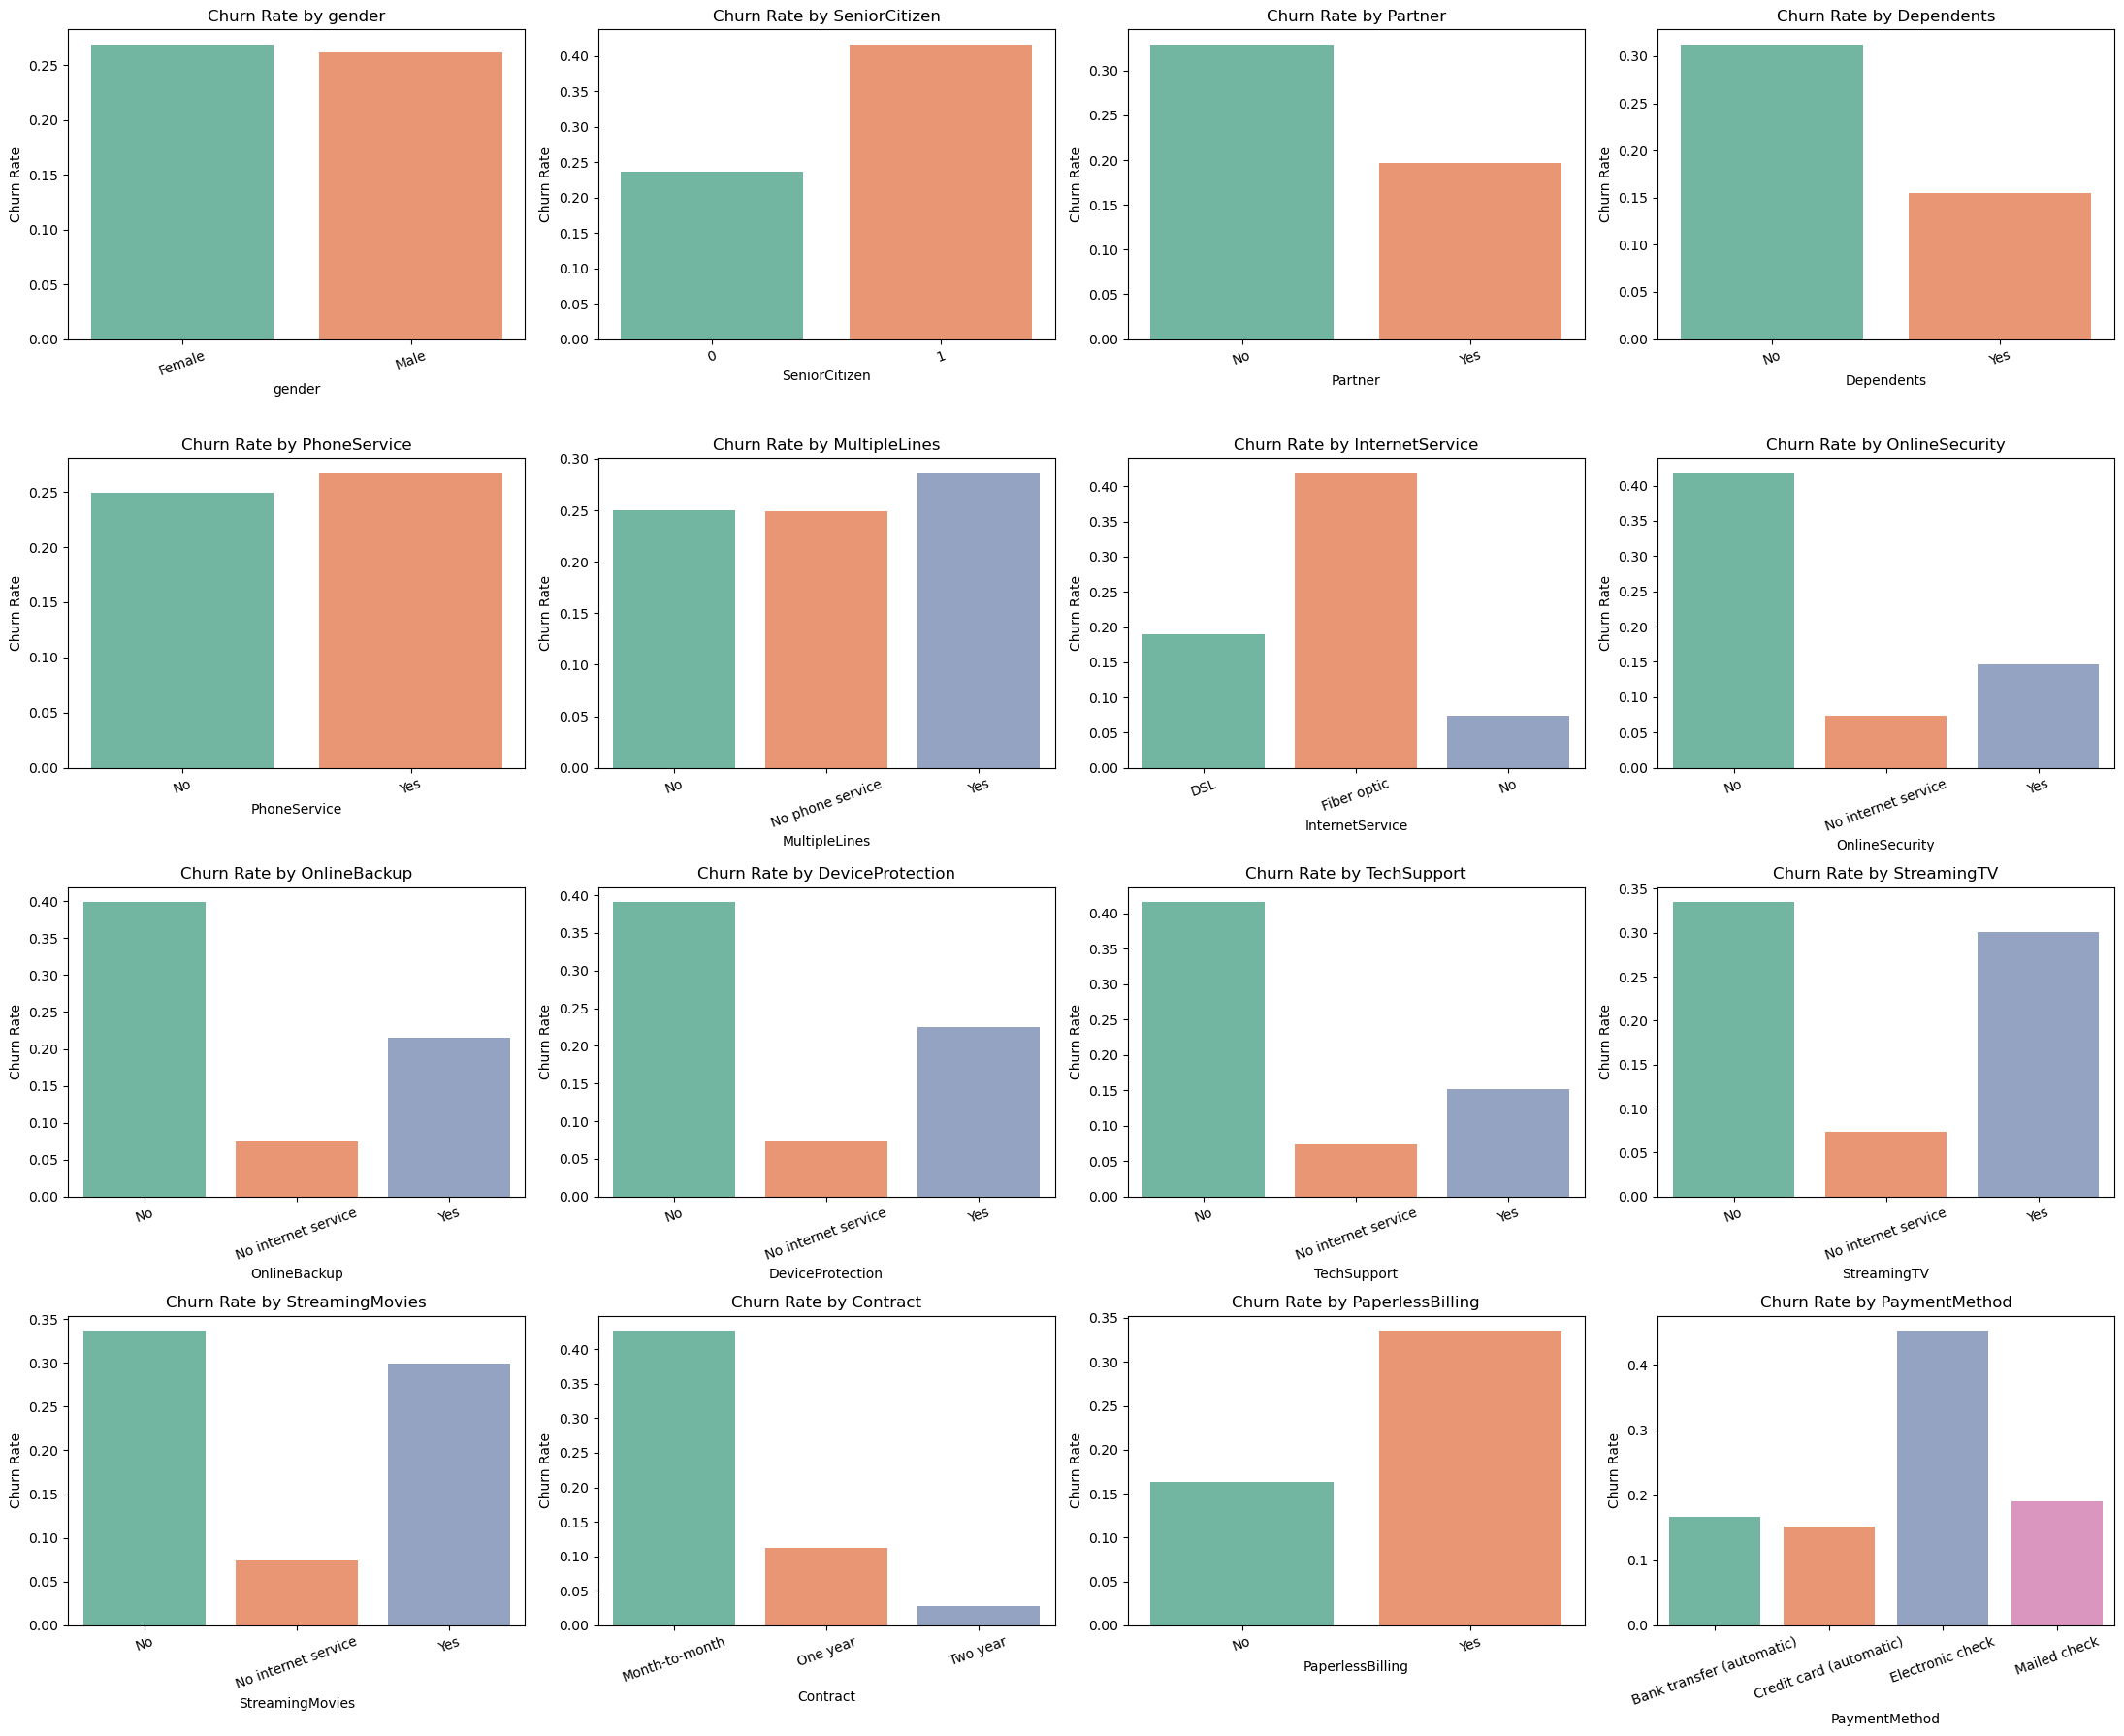

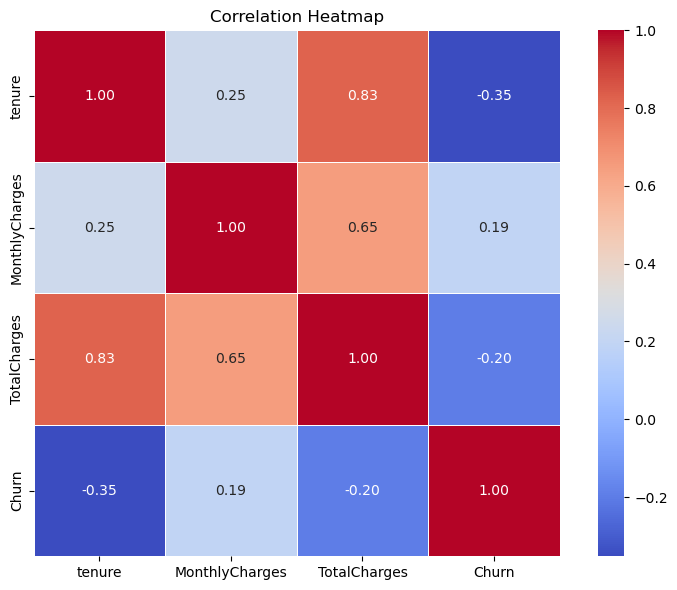

In [8]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['No Churn', 'Churn'],
    colors=['#4C72B0', '#DD8452'], startangle=90, ax=axes[0]
)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('')

sns.countplot(x='Churn', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Churn Count')
axes[1].set_xticklabels(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

# --- Numerical Features Distribution ---
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette='Set2', bins=30, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

# --- Boxplots for Outlier Detection ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, palette='Set2', ax=axes[i])
    axes[i].set_xticklabels(['No Churn', 'Churn'])
    axes[i].set_title(f'{col} — Outlier Check')
plt.tight_layout()
plt.show()

# --- Categorical Features vs Churn ---
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Churn',
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# --- Correlation Heatmap  ---
plt.figure(figsize=(8, 6))
corr = df[num_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



In [9]:
# =============================================================================
# 4. FEATURE ENGINEERING
# =============================================================================

df_fe = df.copy()

# --- 4.1 New Features ---

# Average monthly spend relative to tenure (avoids div-by-zero)
df_fe['AvgMonthlySpend'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

# Engagement score: number of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
# These cols have values: 'Yes', 'No'
for col in addon_cols:
    df_fe[col + '_bin'] = (df_fe[col] == 'Yes').astype(int)

df_fe['AddonCount'] = df_fe[[c + '_bin' for c in addon_cols]].sum(axis=1)

# Tenure bucket (bins: new, mid, long-term)
df_fe['TenureBucket'] = pd.cut(df_fe['tenure'],
                                bins=[0, 12, 36, 72],
                                labels=['New', 'Mid', 'LongTerm'])

# High spender flag (above median monthly charges)
median_charge = df_fe['MonthlyCharges'].median()
df_fe['HighSpender'] = (df_fe['MonthlyCharges'] > median_charge).astype(int)

print("\nNew features added: AvgMonthlySpend, AddonCount, TenureBucket, HighSpender")
print(df_fe[['AvgMonthlySpend', 'AddonCount', 'TenureBucket', 'HighSpender']].head())



New features added: AvgMonthlySpend, AddonCount, TenureBucket, HighSpender
   AvgMonthlySpend  AddonCount TenureBucket  HighSpender
0        14.925000           1          New            0
1        53.985714           2          Mid            0
2        36.050000           2          New            0
3        40.016304           3     LongTerm            0
4        50.550000           0          New            1


In [10]:
# =============================================================================
# 5. PREPARE FEATURES & TARGET — PIPELINE
# =============================================================================

# Separate target
X = df_fe.drop(columns='Churn')
y = df_fe['Churn']

# Drop original addon cols (replaced by binaries) and tenure (bucketed)
X.drop(columns=addon_cols, inplace=True)

# Define feature groups
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                      'AvgMonthlySpend', 'AddonCount']

binary_features = ['SeniorCitizen', 'HighSpender'] + [c + '_bin' for c in addon_cols]

categorical_features = ['gender', 'Partner', 'Dependents',
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'Contract', 'PaperlessBilling', 'PaymentMethod',
                        'TenureBucket']

# --- Pipelines ---
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Binary features only need imputation (already 0/1)
bin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features),
    ('bin', bin_pipeline, binary_features)
])

# --- Fit & Transform ---
X_preprocessed = preprocessor.fit_transform(X)

# --- Recover feature names ---
ohe_cols = preprocessor.named_transformers_['cat']['encoder']\
               .get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + ohe_cols + binary_features

preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
preprocessed_df['Churn'] = y.values

print("\nPreprocessed DataFrame shape:", preprocessed_df.shape)
print(preprocessed_df.head())


Preprocessed DataFrame shape: (7043, 40)
     tenure  MonthlyCharges  TotalCharges  AvgMonthlySpend  AddonCount  \
0 -1.277445       -1.160323     -0.994242        -0.757979   -0.561776   
1  0.066327       -0.259629     -0.173244        -0.117801   -0.020519   
2 -1.236724       -0.362660     -0.959674        -0.411755   -0.020519   
3  0.514251       -0.746535     -0.194766        -0.346750    0.520738   
4 -1.236724        0.197365     -0.940470        -0.174110   -1.103033   

   gender_Female  gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0            1.0          0.0         0.0          1.0            1.0  ...   
1            0.0          1.0         1.0          0.0            1.0  ...   
2            0.0          1.0         1.0          0.0            1.0  ...   
3            0.0          1.0         1.0          0.0            1.0  ...   
4            1.0          0.0         1.0          0.0            1.0  ...   

   TenureBucket_New  SeniorCitizen  HighSpen

In [11]:
# =============================================================================
# 6. SAVE — Three separate splits for saving in S3
# =============================================================================

# First split — train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    preprocessed_df.drop(columns='Churn'),
    preprocessed_df['Churn'],
    test_size=0.3, random_state=42, stratify=preprocessed_df['Churn']
)

# Second split — val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)


# Reconstruct DataFrames with target as first column (SageMaker format)
train_df = pd.concat([y_train.reset_index(drop=True),
                      X_train.reset_index(drop=True)], axis=1)
val_df   = pd.concat([y_val.reset_index(drop=True),
                      X_val.reset_index(drop=True)], axis=1)
test_df  = pd.concat([y_test.reset_index(drop=True),
                      X_test.reset_index(drop=True)], axis=1)



# Save locally
train_df.to_csv('train.csv', index=False, header=False)
val_df.to_csv('validation.csv', index=False, header=False)
test_df.iloc[:, 1:].to_csv('test.csv', index=False, header=False)

print(f"✅ Train size     : {train_df.shape}")
print(f"✅ Validation size: {val_df.shape}")
print(f"✅ Test size      : {test_df.shape}")

BUCKET = 'huzaifas-train-model'
PREFIX = 'telco-churn/data'

s3 = boto3.client('s3')
for filename in ['train.csv', 'validation.csv', 'test.csv']:
    s3.upload_file(filename, BUCKET, f'{PREFIX}/{filename}')
    print(f"✅ Uploaded {filename} to s3://{BUCKET}/{PREFIX}/{filename}")

✅ Train size     : (4930, 40)
✅ Validation size: (1056, 40)
✅ Test size      : (1057, 40)
✅ Uploaded train.csv to s3://huzaifas-train-model/telco-churn/data/train.csv
✅ Uploaded validation.csv to s3://huzaifas-train-model/telco-churn/data/validation.csv
✅ Uploaded test.csv to s3://huzaifas-train-model/telco-churn/data/test.csv


In [12]:
# =============================================================================
# 7. LOAD PREPROCESSED DATA
# =============================================================================
# Load the preprocessed CSV saved from the pipeline script
# (telco_churn_preprocessed.csv has NO header, target is first column)

preprocessed_df = pd.read_csv('telco_churn_preprocessed.csv', header=None)

# Separate features and target
X = preprocessed_df.iloc[:, 1:].values.astype(np.float32)
y = preprocessed_df.iloc[:, 0].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution — 0:", (y == 0).sum(), "| 1:", (y == 1).sum())

X shape: (7043, 39)
y shape: (7043,)
Class distribution — 0: 5174 | 1: 1869


In [13]:
# =============================================================================
# 8. TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# =============================================================================
#  CLASS WEIGHTS
# =============================================================================

# Ratio of majority to minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
print('neg = ',neg)
print('pos = ',pos)
sample_weights = np.where(y_train == 1, neg / pos, 1.0)
# neg/pos = 3635/1310 ≈ 2.77
print (sample_weights)


Train: 4930 | Val: 1056 | Test: 1057
neg =  3622
pos =  1308
[1.         2.76911315 2.76911315 ... 1.         1.         1.        ]


Setup SageMaker

In [14]:
session = sagemaker.Session()
role = get_execution_role()

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


Defining XGBoost Estimator

In [15]:
container = sagemaker.image_uris.retrieve(
    framework='xgboost',
    region=session.boto_region_name,
    version='1.5-1'
)

xgb = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.large',
    output_path=f's3://huzaifas-train-model/telco-churn/output/'
)

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.Subnets
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.SecurityGroupIds
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment


Set Hyperparameters

In [16]:
xgb.set_hyperparameters(
    objective='binary:logistic',
    num_round=100,
    max_depth=3,
    eta=0.1,
    subsample=0.8,
    eval_metric='auc'
)

Define Data Channels

In [17]:
train_input = TrainingInput(
    's3://huzaifas-train-model/telco-churn/data/train.csv',
    content_type='csv'
)

val_input = TrainingInput(
    's3://huzaifas-train-model/telco-churn/data/validation.csv',
    content_type='csv'
)

Train XGBoost Model

In [18]:
# Trains one XGBoost model using the fixed hyperparameters
xgb.fit({
    'train': train_input,
    'validation': val_input
})

2026-03-19 20:26:52 Starting - Starting the training job...
2026-03-19 20:27:13 Starting - Preparing the instances for training...
2026-03-19 20:27:36 Downloading - Downloading input data...
2026-03-19 20:28:27 Downloading - Downloading the training image......
2026-03-19 20:29:18 Training - Training image download completed. Training in progress../miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2026-03-19 20:29:23.701 ip-172-31-145-57.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-19 20:29:23.725 ip-172-31-145-57.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-03-19:20:29:24:INFO] Imported framework sagemaker_xgboost_container.training
[2026-03-19:20:29:24:INFO] Failed to parse hyperparameter eval_metric value 

STEP 1: Hyperparameter Tuning (HPO)

In [19]:
hyperparameter_ranges = {
    'max_depth': IntegerParameter(3, 10),
    'eta': ContinuousParameter(0.1, 0.5),
    'subsample': ContinuousParameter(0.5, 1.0)
}

tuner = HyperparameterTuner(
    estimator=xgb,
    objective_metric_name='validation:auc',
    hyperparameter_ranges=hyperparameter_ranges,
    max_jobs=10,
    max_parallel_jobs=2,
    early_stopping_type='Auto'
)

# picks one combination of hyperparameters
# launches a new training job
# trains a fresh model from scratch
# checks validation:auc
# repeats with other combinations
# compares all jobs
# selects the best one

tuner.fit({
    'train': train_input,
    'validation': val_input
})

...............................................................................................!


STEP 2: Get Best Model

In [ ]:
# Gives final best trained model
best_model = tuner.best_estimator()

STEP 3: Batch Inference

In [21]:
transformer = best_model.transformer(
    instance_count=1,
    instance_type='ml.m5.large',
    output_path=f's3://huzaifas-train-model/telco-churn/output'
)

transformer.transform(
    data='s3://huzaifas-train-model/telco-churn/data/test.csv',
    content_type='text/csv'
)

transformer.wait()

................................./miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2026-03-19:21:16:27:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-19:21:16:27:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-19:21:16:27:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocations|execution-parameters) {
      proxy_set_header X-Forwarded-For $proxy_a

STEP 4: Evaluation

In [24]:
s3 = boto3.client('s3')

# Output file is named same as input + .out extension
obj = s3.get_object(
    Bucket='huzaifas-train-model',
    Key='telco-churn/output/test.csv.out'
)

predictions = pd.read_csv(io.BytesIO(obj['Body'].read()), header=None)
predictions.columns = ['predicted_prob']

# Convert probabilities to binary predictions
threshold = 0.3
predictions['predicted_label'] = (predictions['predicted_prob'] >= threshold).astype(int)

print(predictions.head())
print("\nPrediction distribution:\n", predictions['predicted_label'].value_counts())

   predicted_prob  predicted_label
0        0.167499                0
1        0.218309                0
2        0.007373                0
3        0.032779                0
4        0.000835                0

Prediction distribution:
 predicted_label
0    751
1    306
Name: count, dtype: int64


AUC - ROC

In [ ]:
y_true = y_test

AUC Score: 0.8076572073228895


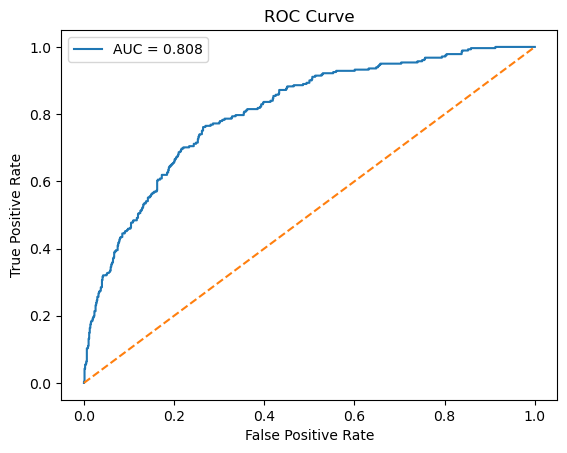

In [34]:
# AUC score
auc = roc_auc_score(y_true, predictions['predicted_prob'])
print("AUC Score:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, predictions['predicted_prob'])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

F1 Score, Precision, Recall, Confusion Matrix

Precision = out of predicted churns, how many were actually churn

Recall = out of actual churns, how many you caught

F1 = balance of precision and recall

In [ ]:
# Metrics
f1 = f1_score(y_true, predictions['predicted_label'])
precision = precision_score(y_true, predictions['predicted_label'])
recall = recall_score(y_true, predictions['predicted_label'])

print("F1-score :", f1)
print("Precision:", precision)
print("Recall   :", recall)

# Confusion Matrix
cm = confusion_matrix(y_true, predictions['predicted_label'])
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Step 5: Model Registration

In [36]:
model = Model(
    image_uri=xgb.image_uri,
    model_data=xgb.model_data,
    role=role,
    sagemaker_session=session
)

model.register(
    content_types=["text/csv"],
    response_types=["text/csv"],
    inference_instances=["ml.m5.large"],
    transform_instances=["ml.m5.large"],
    model_package_group_name="churn-model-group"
)

sagemaker.config INFO - Applied value from config key = SageMaker.Model.VpcConfig
sagemaker.config INFO - Applied value from config key = SageMaker.Model.VpcConfig
